# EDA — Open-Set DGA Detection Dataset
Exploratory data analysis in order:
1. Imports & Setup
2. Load Data
3. Basic Statistics & Data Quality
4. Sanity Checks (zero-leakage verification)
5. Feature Engineering
6. Feature Distribution (KDE + Boxplot)
7. Entropy Detail Analysis
8. Per-Family Entropy Boxplot
9. Multivariate Analysis (Correlation + Scatter)
10. t-SNE Visualization
11. TLD Distribution
12. DGA Family Distribution
13. OOD Source Analysis
14. Domain Length Analysis
15. Statistical Summary Table
16. Key Insights

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import math
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Publication-ready style ──────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.dpi':        120,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
})

# ── Consistent color palette for 4 groups ───────────────────────────────────
GROUP_COLORS = {
    'Known Benign':  '#2563EB',
    'Known DGA':     '#EA580C',
    'Unknown DGA':   '#16A34A',
    'OOD':           '#9333EA'
}
GROUP_ORDER = ['Known Benign', 'Known DGA', 'Unknown DGA', 'OOD']

FIGURE_DIR = Path('../figures/EDA')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')
print(f'Figures -> {FIGURE_DIR.resolve()}')

Imports OK
Figures -> D:\004. HK2 Năm 3\01. DS108\OpenSetDGA-Detection\figures\EDA


## 2. Load Data

In [2]:
base_path = Path('../data/processed')

df_train          = pd.read_csv(base_path / 'known'          / 'train.csv')
df_val            = pd.read_csv(base_path / 'known'          / 'val.csv')
df_test_known     = pd.read_csv(base_path / 'known'          / 'test_known.csv')
df_unknown_family = pd.read_csv(base_path / 'unknown_family' / 'test_unknown_family.csv')
df_unknown_ood    = pd.read_csv(base_path / 'unknown_ood'    / 'test_unknown_ood.csv')

datasets = {
    'Train':          df_train,
    'Validation':     df_val,
    'Test Known':     df_test_known,
    'Unknown Family': df_unknown_family,
    'OOD':            df_unknown_ood
}

for name, df in datasets.items():
    print(f'\n===== {name} =====')
    print(f'  Rows : {df.shape[0]:,}  |  Cols: {df.shape[1]}')
    print(f'  Cols : {list(df.columns)}')

print('\nLoaded successfully.')


===== Train =====
  Rows : 320,000  |  Cols: 7
  Cols : ['domain', 'family', 'source', 'label', 'split', 'class_label', 'split_hint']

===== Validation =====
  Rows : 40,000  |  Cols: 7
  Cols : ['domain', 'family', 'source', 'label', 'split', 'class_label', 'split_hint']

===== Test Known =====
  Rows : 40,000  |  Cols: 7
  Cols : ['domain', 'family', 'source', 'label', 'split', 'class_label', 'split_hint']

===== Unknown Family =====
  Rows : 50,000  |  Cols: 7
  Cols : ['domain', 'family', 'source', 'label', 'split', 'class_label', 'split_hint']

===== OOD =====
  Rows : 100,000  |  Cols: 7
  Cols : ['domain', 'family', 'source', 'label', 'class_label', 'split_hint', 'split']

Loaded successfully.


## 3. Basic Statistics & Data Quality

In [3]:
print('Dataset sizes:')
total = 0
for name, df in datasets.items():
    print(f'  {name:20s}: {df.shape[0]:>8,} rows')
    total += df.shape[0]
print(f'  {"TOTAL":20s}: {total:>8,} rows')

Dataset sizes:
  Train               :  320,000 rows
  Validation          :   40,000 rows
  Test Known          :   40,000 rows
  Unknown Family      :   50,000 rows
  OOD                 :  100,000 rows
  TOTAL               :  550,000 rows


In [4]:
print('Train label distribution:')
print(df_train['label'].value_counts())
print('\nTrain family distribution (top 10):')
print(df_train['family'].value_counts().head(10))

Train label distribution:
label
dga       160083
benign    159917
Name: count, dtype: int64

Train family distribution (top 10):
family
benign      159917
nymaim        9225
simda         9211
ramdo         9194
pykspa        9191
rovnix        9190
suppobox      9181
dircrypt      9173
matsnu        9171
padcrypt      9169
Name: count, dtype: int64


In [5]:
print('Missing values per split:')
for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    status = 'OK' if total_missing == 0 else f'WARNING: {total_missing} missing'
    print(f'  {name:20s}: {status}')

Missing values per split:
  Train               : OK
  Validation          : OK
  Test Known          : OK
  Unknown Family      : OK
  OOD                 : OK


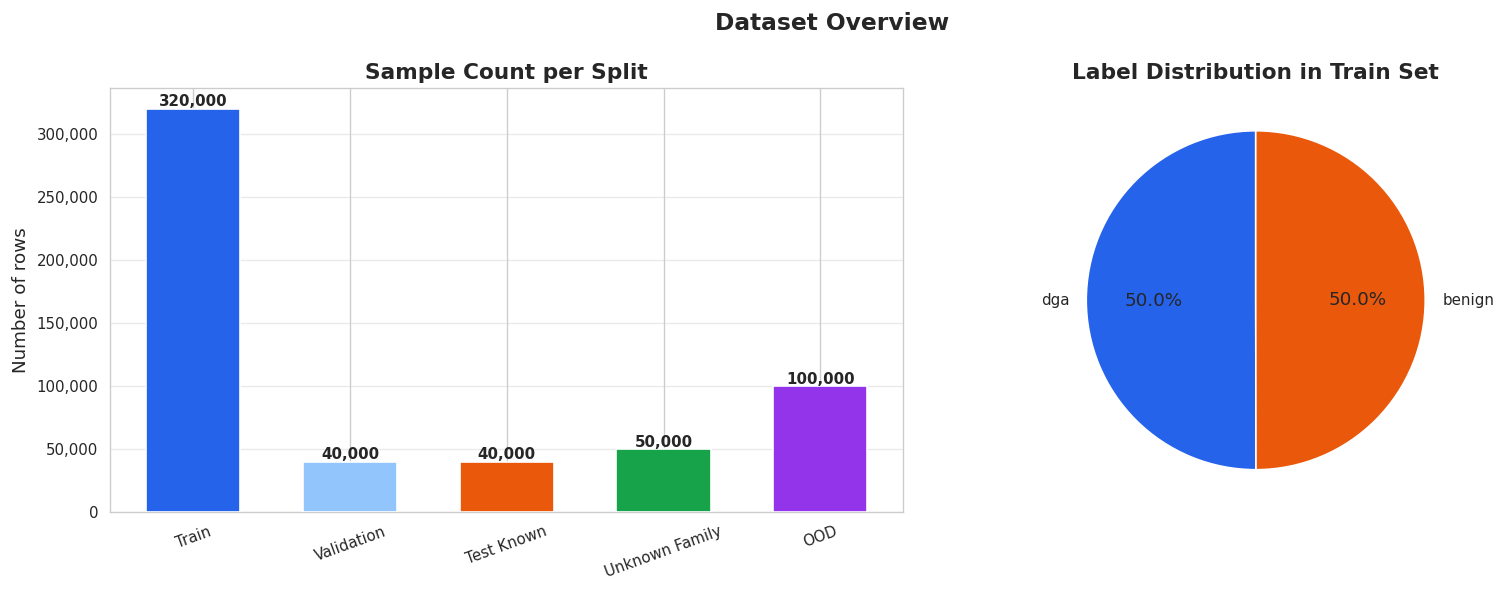

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — split sizes
split_names = list(datasets.keys())
split_sizes = [len(df) for df in datasets.values()]
bar_colors  = ['#2563EB', '#93C5FD', '#EA580C', '#16A34A', '#9333EA']
bars = axes[0].bar(split_names, split_sizes, color=bar_colors, zorder=3, width=0.6)
for bar, v in zip(bars, split_sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 2000,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Sample Count per Split')
axes[0].set_ylabel('Number of rows')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='y', alpha=0.4)

# Panel B — label distribution in train
label_counts = df_train['label'].value_counts()
wedge_colors = ['#2563EB', '#EA580C']
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', startangle=90, colors=wedge_colors,
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
axes[1].set_title('Label Distribution in Train Set')

fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_01_split_overview.png')
plt.show()

## 4. Sanity Checks — Zero Leakage Verification
> Verify that no domain appears in more than one split (no data leakage).

In [7]:
train_domains   = set(df_train['domain'])
val_domains     = set(df_val['domain'])
test_domains    = set(df_test_known['domain'])
unknown_domains = set(df_unknown_family['domain'])
ood_domains     = set(df_unknown_ood['domain'])

checks = [
    ('Train ∩ Val',            train_domains   & val_domains),
    ('Train ∩ Test Known',     train_domains   & test_domains),
    ('Train ∩ Unknown Family', train_domains   & unknown_domains),
    ('Train ∩ OOD',            train_domains   & ood_domains),
    ('Test Known ∩ Unknown',   test_domains    & unknown_domains),
    ('Unknown Family ∩ OOD',   unknown_domains & ood_domains),
]

all_ok = True
for name, overlap in checks:
    status = '[ OK ]' if len(overlap) == 0 else '[LEAK DETECTED]'
    if len(overlap) > 0:
        all_ok = False
    print(f'  {name:35s}: {len(overlap):>5} overlap  {status}')

print()
if all_ok:
    print('ZERO DATA LEAKAGE confirmed — all splits are clean.')
else:
    print('WARNING: leakage detected — check pipeline.')

# Family hold-out check
train_families   = set(df_train['family'].unique())
unknown_families = set(df_unknown_family['family'].unique())
family_overlap   = train_families & unknown_families
print(f'\n  Family overlap train ∩ unknown_family (must be 0): {len(family_overlap)}')
print(f'  Hold-out families: {sorted(unknown_families)}')

  Train ∩ Val                        :     0 overlap  [ OK ]
  Train ∩ Test Known                 :     0 overlap  [ OK ]
  Train ∩ Unknown Family             :     0 overlap  [ OK ]
  Train ∩ OOD                        :     0 overlap  [ OK ]
  Test Known ∩ Unknown               :     0 overlap  [ OK ]
  Unknown Family ∩ OOD               :     0 overlap  [ OK ]

ZERO DATA LEAKAGE confirmed — all splits are clean.

  Family overlap train ∩ unknown_family (must be 0): 0
  Hold-out families: ['fobber', 'pushdo', 'qadars', 'ranbyus', 'vawtrak']


## 5. Feature Engineering
Extract 6 lexical features from domain strings for visualization.

In [8]:
VOWELS = set('aeiou')

def shannon_entropy(s):
    if not s: return 0.0
    counts = Counter(s)
    n = len(s)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())

def bigram_diversity(s):
    s = s.lower()
    bigrams = [s[i:i+2] for i in range(len(s) - 1)]
    return len(set(bigrams)) / len(bigrams) if bigrams else 0.0

def add_features(df):
    df = df.copy()
    clean  = df['domain'].str.lower().str.strip()
    no_dot = clean.str.replace('.', '', regex=False)
    df['length']           = clean.apply(len)
    df['entropy']          = no_dot.apply(shannon_entropy)
    df['digit_ratio']      = no_dot.apply(lambda s: sum(c.isdigit() for c in s) / max(len(s), 1))
    df['vowel_ratio']      = no_dot.apply(lambda s: sum(c in VOWELS for c in s)  / max(len(s), 1))
    df['bigram_diversity'] = no_dot.apply(bigram_diversity)
    df['unique_char_ratio']= no_dot.apply(lambda s: len(set(s)) / max(len(s), 1))
    df['tld']              = clean.apply(lambda s: s.split('.')[-1] if '.' in s else '')
    return df

# Build 4-group dataframe for comparison
df_benign     = add_features(df_test_known[df_test_known['label'] == 'benign'].copy())
df_known_dga  = add_features(df_test_known[df_test_known['label'] == 'dga'].copy())
df_unk_family = add_features(df_unknown_family.copy())
df_ood_feat   = add_features(df_unknown_ood.copy())

df_benign['group']     = 'Known Benign'
df_known_dga['group']  = 'Known DGA'
df_unk_family['group'] = 'Unknown DGA'
df_ood_feat['group']   = 'OOD'

df_all = pd.concat([df_benign, df_known_dga, df_unk_family, df_ood_feat], ignore_index=True)
print(f'df_all shape: {df_all.shape}')
print(df_all['group'].value_counts())

df_all shape: (190000, 15)
group
OOD             100000
Unknown DGA      50000
Known Benign     20043
Known DGA        19957
Name: count, dtype: int64


## 6. Feature Distribution — KDE & Boxplot

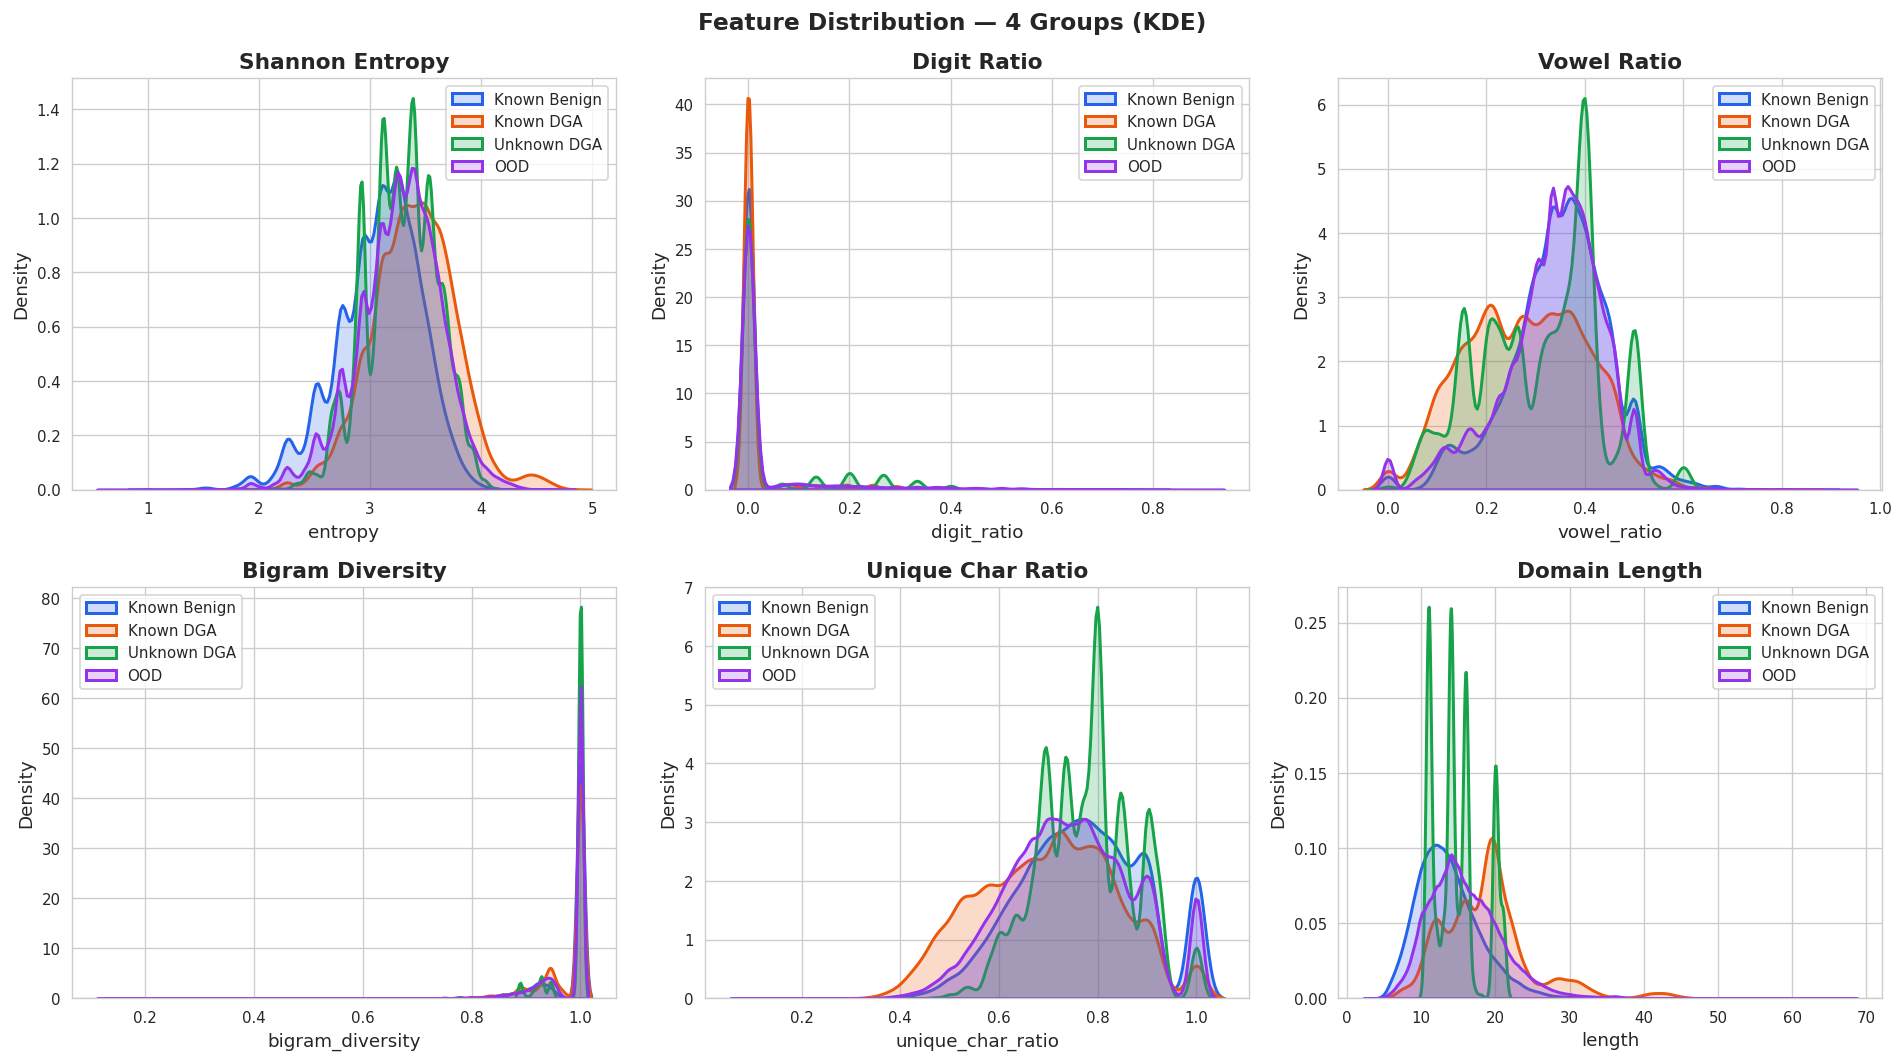

In [9]:
FEATURES = [
    ('entropy',           'Shannon Entropy'),
    ('digit_ratio',       'Digit Ratio'),
    ('vowel_ratio',       'Vowel Ratio'),
    ('bigram_diversity',  'Bigram Diversity'),
    ('unique_char_ratio', 'Unique Char Ratio'),
    ('length',            'Domain Length'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (feat, title) in zip(axes.flat, FEATURES):
    for group in GROUP_ORDER:
        subset = df_all[df_all['group'] == group]
        sns.kdeplot(subset[feat], ax=ax, label=group,
                    color=GROUP_COLORS[group], fill=True, alpha=0.22, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

fig.suptitle('Feature Distribution — 4 Groups (KDE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_02_kde_features.png')
plt.show()

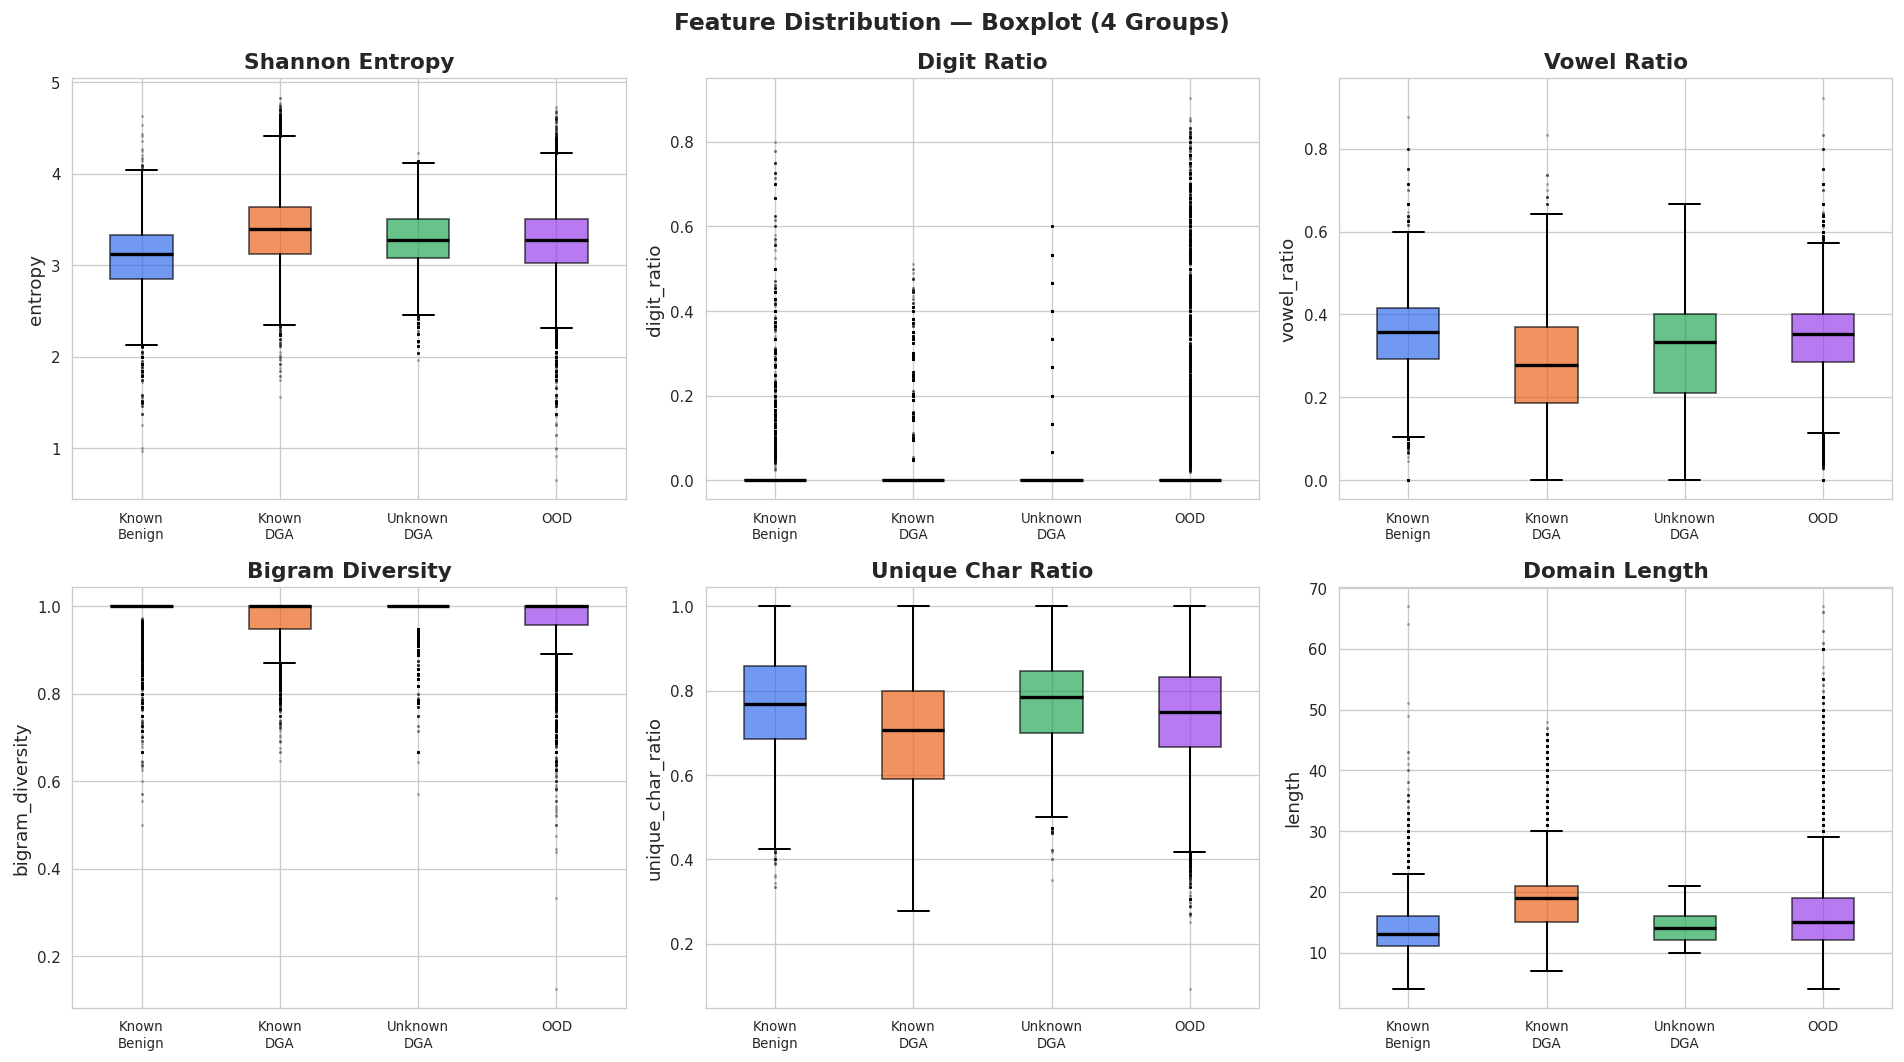

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (feat, title) in zip(axes.flat, FEATURES):
    data_by_group = [df_all[df_all['group'] == g][feat].dropna().values for g in GROUP_ORDER]
    bp = ax.boxplot(data_by_group, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=1.5, alpha=0.3),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    for patch, g in zip(bp['boxes'], GROUP_ORDER):
        patch.set_facecolor(GROUP_COLORS[g])
        patch.set_alpha(0.65)
    ax.set_xticks(range(1, len(GROUP_ORDER) + 1))
    ax.set_xticklabels([g.replace(' ', '\n') for g in GROUP_ORDER], fontsize=8)
    ax.set_title(title)
    ax.set_ylabel(feat)

fig.suptitle('Feature Distribution — Boxplot (4 Groups)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_03_boxplot_features.png')
plt.show()

## 7. Entropy Detail Analysis
Entropy is the most discriminative feature for DGA detection.

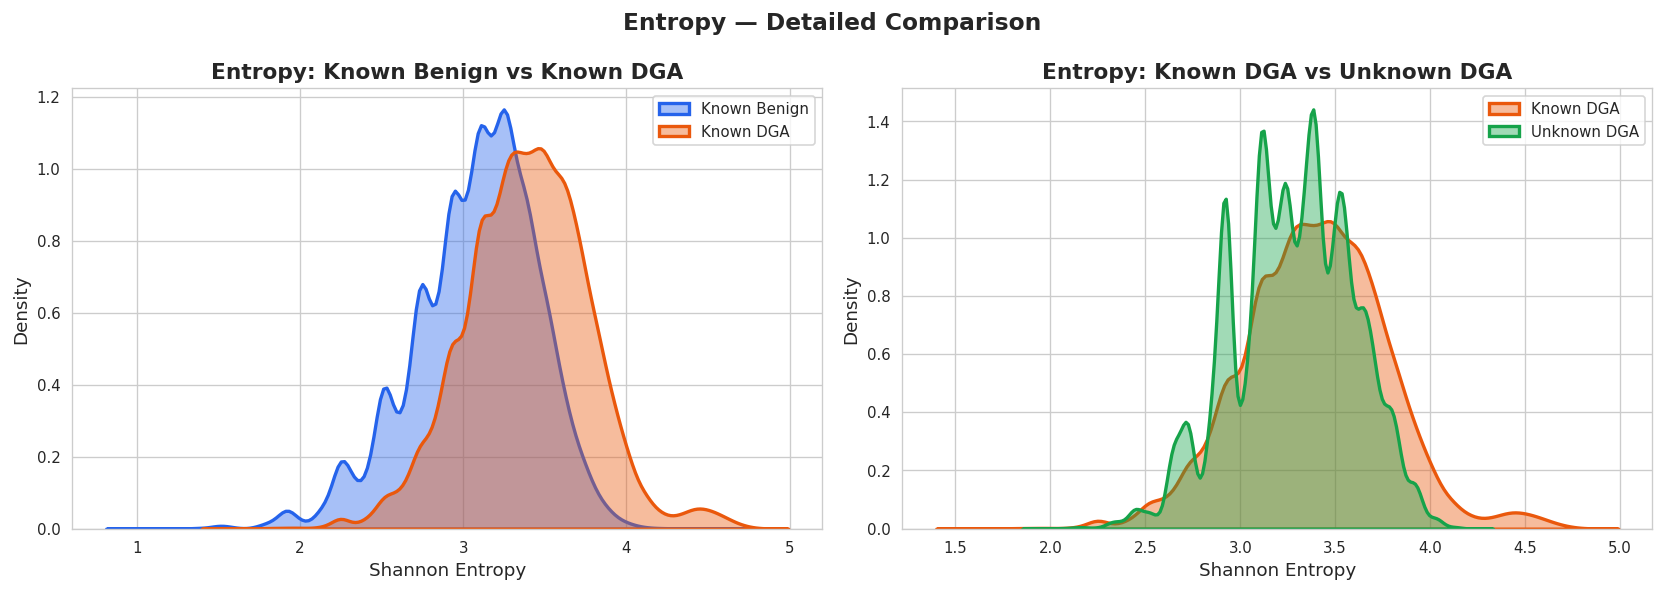

Observation: Known DGA and Unknown DGA share similar entropy distributions, confirming that open-set detection is harder than closed-set.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Known Benign vs Known DGA
ax = axes[0]
for g, df_g in [('Known Benign', df_benign), ('Known DGA', df_known_dga)]:
    sns.kdeplot(df_g['entropy'], ax=ax, label=g,
                color=GROUP_COLORS[g], fill=True, alpha=0.4, linewidth=2)
ax.set_title('Entropy: Known Benign vs Known DGA')
ax.set_xlabel('Shannon Entropy')
ax.set_ylabel('Density')
ax.legend()

# Panel B: Known DGA vs Unknown DGA
ax2 = axes[1]
for g, df_g in [('Known DGA', df_known_dga), ('Unknown DGA', df_unk_family)]:
    sns.kdeplot(df_g['entropy'], ax=ax2, label=g,
                color=GROUP_COLORS[g], fill=True, alpha=0.4, linewidth=2)
ax2.set_title('Entropy: Known DGA vs Unknown DGA')
ax2.set_xlabel('Shannon Entropy')
ax2.set_ylabel('Density')
ax2.legend()

fig.suptitle('Entropy — Detailed Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_04_entropy_detail.png')
plt.show()
print('Observation: Known DGA and Unknown DGA share similar entropy distributions,'
      ' confirming that open-set detection is harder than closed-set.')

## 8. Per-Family Entropy Boxplot
Compare entropy distribution **within each DGA family** — known (orange) vs hold-out unknown (green).
This reveals whether hold-out families are outliers or blend with known families.

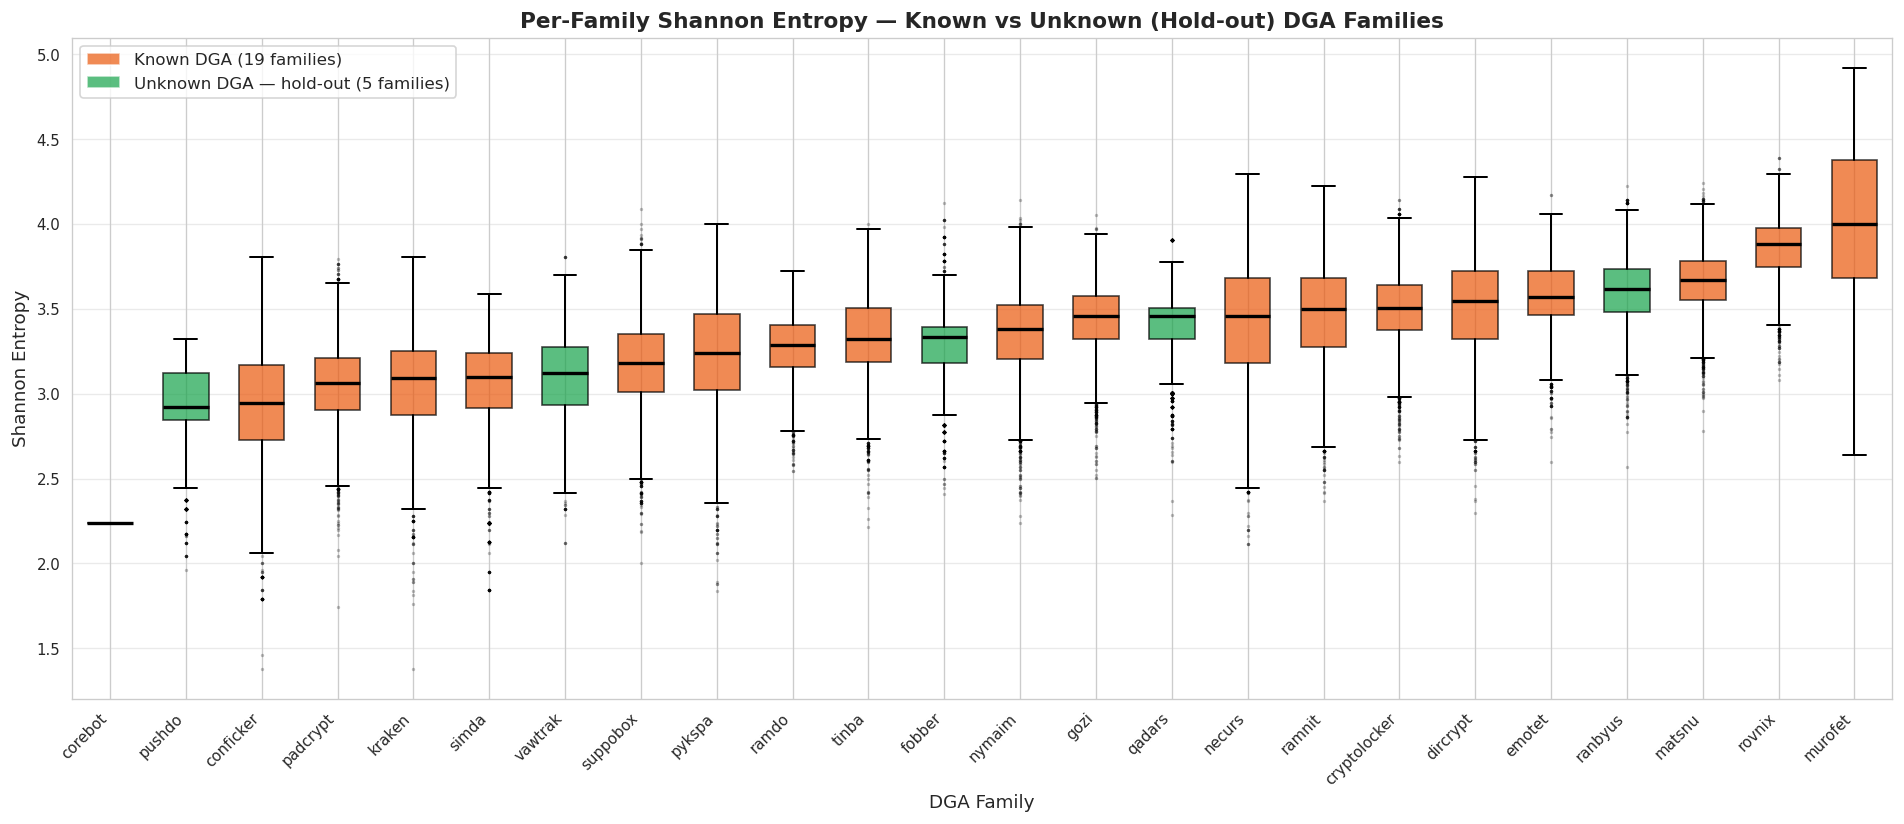

Median entropy per family (sorted):
  [Known  ]  corebot          median entropy = 2.236
  [Unknown]  pushdo           median entropy = 2.922
  [Known  ]  conficker        median entropy = 2.948
  [Known  ]  padcrypt         median entropy = 3.066
  [Known  ]  kraken           median entropy = 3.093
  [Known  ]  simda            median entropy = 3.096
  [Unknown]  vawtrak          median entropy = 3.122
  [Known  ]  suppobox         median entropy = 3.182
  [Known  ]  pykspa           median entropy = 3.240
  [Known  ]  ramdo            median entropy = 3.287
  [Known  ]  tinba            median entropy = 3.325
  [Unknown]  fobber           median entropy = 3.335
  [Known  ]  nymaim           median entropy = 3.379
  [Known  ]  gozi             median entropy = 3.456
  [Unknown]  qadars           median entropy = 3.457
  [Known  ]  necurs           median entropy = 3.459
  [Known  ]  ramnit           median entropy = 3.500
  [Known  ]  cryptolocker     median entropy = 3.507
  [Known  

In [12]:
df_train_feat = add_features(df_train.copy())

# Combine known DGA (from train) + unknown DGA families
df_known_fam  = df_train_feat[df_train_feat['label'] == 'dga'][['family', 'entropy']].copy()
df_known_fam['type'] = 'Known'

df_unk_fam2 = df_unk_family[['family', 'entropy']].copy()
df_unk_fam2['type'] = 'Unknown (hold-out)'

df_fam_all = pd.concat([df_known_fam, df_unk_fam2], ignore_index=True)

# Sort families by median entropy
family_median = df_fam_all.groupby('family')['entropy'].median().sort_values()
family_order  = family_median.index.tolist()

# Separate known vs unknown for coloring
known_families   = df_known_fam['family'].unique().tolist()
unknown_families = df_unk_fam2['family'].unique().tolist()

fig, ax = plt.subplots(figsize=(16, 7))

# Draw boxplot per family, color-coded by type
positions = list(range(len(family_order)))
box_data  = [df_fam_all[df_fam_all['family'] == fam]['entropy'].dropna().values
             for fam in family_order]
box_colors = ['#EA580C' if fam in known_families else '#16A34A'
              for fam in family_order]

bp = ax.boxplot(box_data, positions=positions, patch_artist=True,
                notch=False, vert=True,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.25),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                widths=0.6)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(family_order, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('DGA Family')
ax.set_ylabel('Shannon Entropy')
ax.set_title('Per-Family Shannon Entropy — Known vs Unknown (Hold-out) DGA Families',
             fontsize=13, fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(facecolor='#EA580C', alpha=0.7, label=f'Known DGA ({len(known_families)} families)'),
    mpatches.Patch(facecolor='#16A34A', alpha=0.7, label=f'Unknown DGA — hold-out ({len(unknown_families)} families)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_05_per_family_entropy.png')
plt.show()

# Print median entropy per family
print('Median entropy per family (sorted):')
for fam in family_order:
    ftype = 'Known  ' if fam in known_families else 'Unknown'
    med   = df_fam_all[df_fam_all['family'] == fam]['entropy'].median()
    print(f'  [{ftype}]  {fam:15s}  median entropy = {med:.3f}')

## 9. Multivariate Analysis — Correlation & Scatter

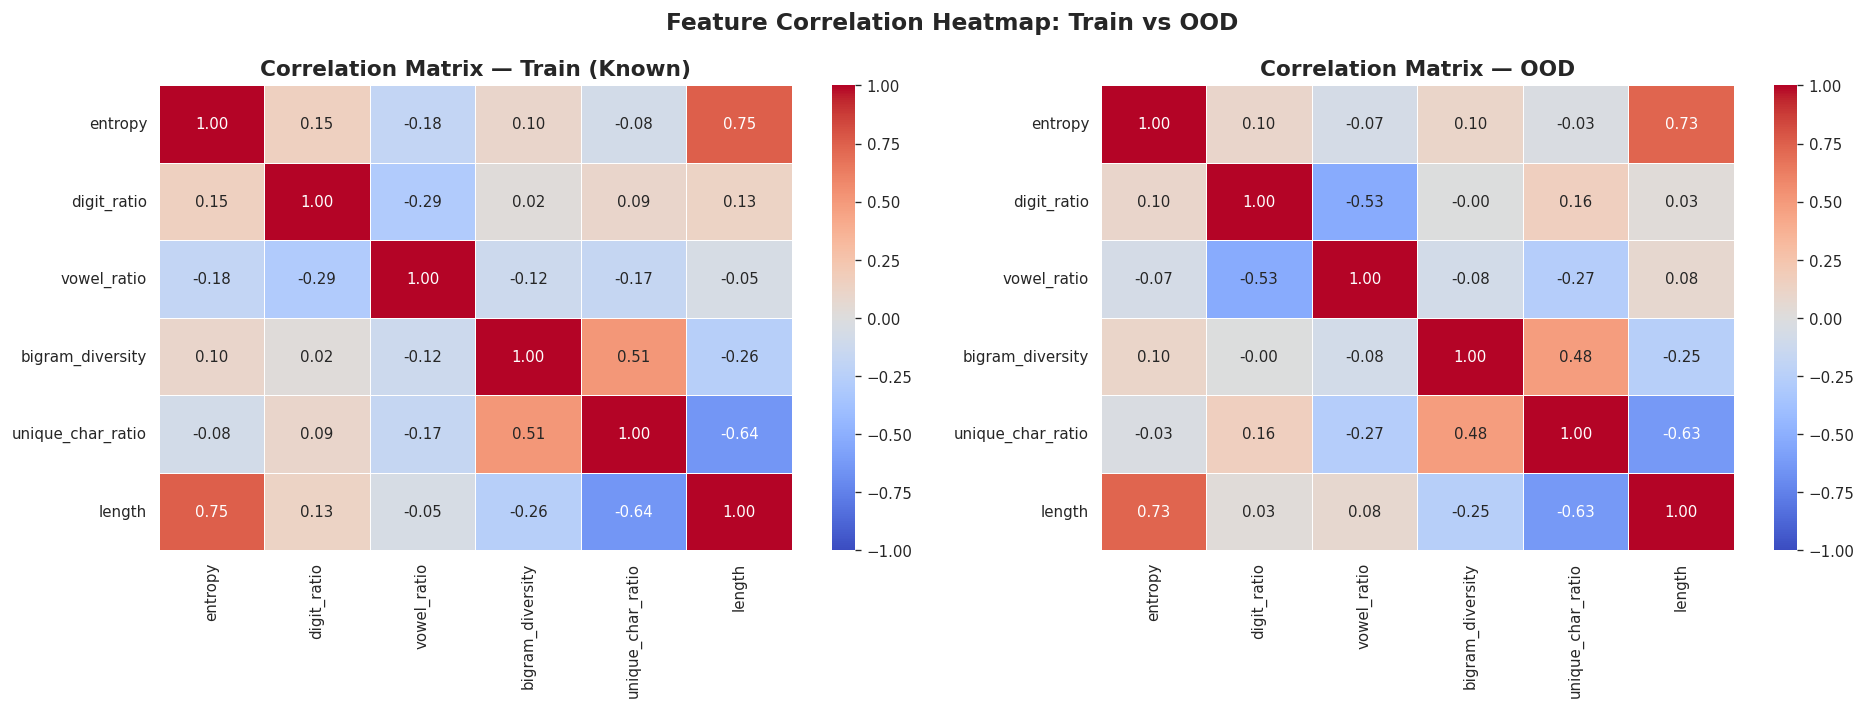

Observation: vowel_ratio is negatively correlated with entropy in both splits. digit_ratio shows low correlation with entropy — orthogonal features.


In [13]:
FEAT_COLS = ['entropy', 'digit_ratio', 'vowel_ratio',
             'bigram_diversity', 'unique_char_ratio', 'length']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap — Train (known)
corr_train = df_train_feat[FEAT_COLS].corr()
sns.heatmap(corr_train, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
axes[0].set_title('Correlation Matrix — Train (Known)')

# Correlation heatmap — OOD
corr_ood = df_ood_feat[FEAT_COLS].corr()
sns.heatmap(corr_ood, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
axes[1].set_title('Correlation Matrix — OOD')

fig.suptitle('Feature Correlation Heatmap: Train vs OOD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_06_correlation_heatmap.png')
plt.show()
print('Observation: vowel_ratio is negatively correlated with entropy in both splits.'
      ' digit_ratio shows low correlation with entropy — orthogonal features.')

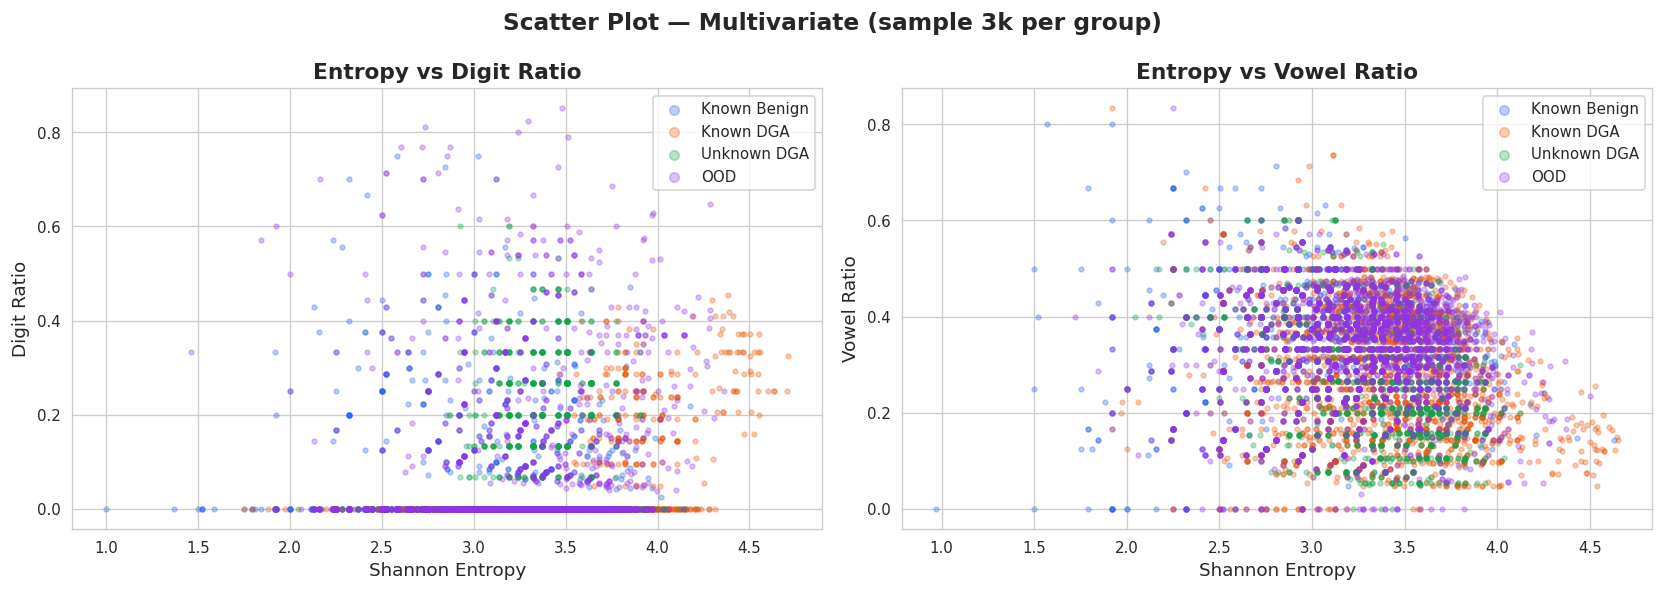

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rng = np.random.default_rng(42)
SAMPLE_N = 3000

# Panel A: Entropy vs Digit Ratio
for group in GROUP_ORDER:
    sub = df_all[df_all['group'] == group]
    idx = rng.choice(len(sub), size=min(SAMPLE_N, len(sub)), replace=False)
    axes[0].scatter(sub.iloc[idx]['entropy'], sub.iloc[idx]['digit_ratio'],
                    c=GROUP_COLORS[group], label=group, alpha=0.3, s=8)
axes[0].set_xlabel('Shannon Entropy')
axes[0].set_ylabel('Digit Ratio')
axes[0].set_title('Entropy vs Digit Ratio')
axes[0].legend(markerscale=2)

# Panel B: Entropy vs Vowel Ratio
for group in GROUP_ORDER:
    sub = df_all[df_all['group'] == group]
    idx = rng.choice(len(sub), size=min(SAMPLE_N, len(sub)), replace=False)
    axes[1].scatter(sub.iloc[idx]['entropy'], sub.iloc[idx]['vowel_ratio'],
                    c=GROUP_COLORS[group], label=group, alpha=0.3, s=8)
axes[1].set_xlabel('Shannon Entropy')
axes[1].set_ylabel('Vowel Ratio')
axes[1].set_title('Entropy vs Vowel Ratio')
axes[1].legend(markerscale=2)

fig.suptitle('Scatter Plot — Multivariate (sample 3k per group)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_07_scatter_multivariate.png')
plt.show()

## 10. t-SNE Visualization
Reduce 6 features to 2D — visualize group separability.

Running t-SNE on 8000 samples...
Done.


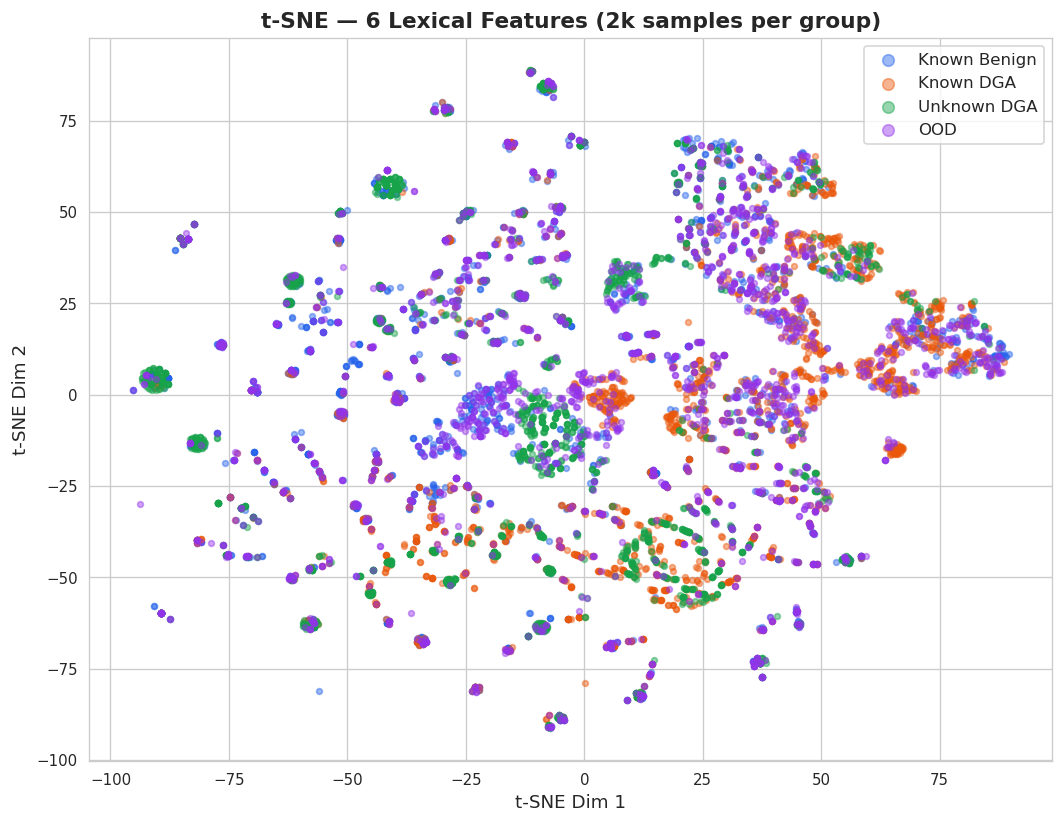

Observation: Known Benign and Known DGA show strong separation. OOD overlaps heavily with Benign — explains lower AUROC on unknown_ood.


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

TSNE_SAMPLE = 2000
rng2 = np.random.default_rng(42)

parts = []
for group in GROUP_ORDER:
    sub = df_all[df_all['group'] == group][FEAT_COLS + ['group']].dropna()
    idx = rng2.choice(len(sub), size=min(TSNE_SAMPLE, len(sub)), replace=False)
    parts.append(sub.iloc[idx])

df_tsne_input = pd.concat(parts, ignore_index=True)
X = StandardScaler().fit_transform(df_tsne_input[FEAT_COLS].values)

print(f'Running t-SNE on {len(X)} samples...')
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
Z = tsne.fit_transform(X)
print('Done.')

fig, ax = plt.subplots(figsize=(9, 7))
for group in GROUP_ORDER:
    mask = df_tsne_input['group'].values == group
    ax.scatter(Z[mask, 0], Z[mask, 1],
               c=GROUP_COLORS[group], label=group, alpha=0.45, s=12)

ax.set_title('t-SNE — 6 Lexical Features (2k samples per group)')
ax.set_xlabel('t-SNE Dim 1')
ax.set_ylabel('t-SNE Dim 2')
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_08_tsne.png')
plt.show()
print('Observation: Known Benign and Known DGA show strong separation.'
      ' OOD overlaps heavily with Benign — explains lower AUROC on unknown_ood.')

## 11. TLD Distribution

In [16]:
for group in GROUP_ORDER:
    print(f'\nTop 5 TLD — {group}')
    print(df_all[df_all['group'] == group]['tld'].value_counts().head(5))


Top 5 TLD — Known Benign
tld
com    8683
net    1031
ru      877
org     768
de      526
Name: count, dtype: int64

Top 5 TLD — Known DGA
tld
com     6829
net     2181
org     1768
eu      1417
info    1298
Name: count, dtype: int64

Top 5 TLD — Unknown DGA
tld
com    21358
ru     10042
net     4648
org     3296
top     3221
Name: count, dtype: int64

Top 5 TLD — OOD
tld
com     44212
net      5530
top      2686
org      2333
info     2259
Name: count, dtype: int64


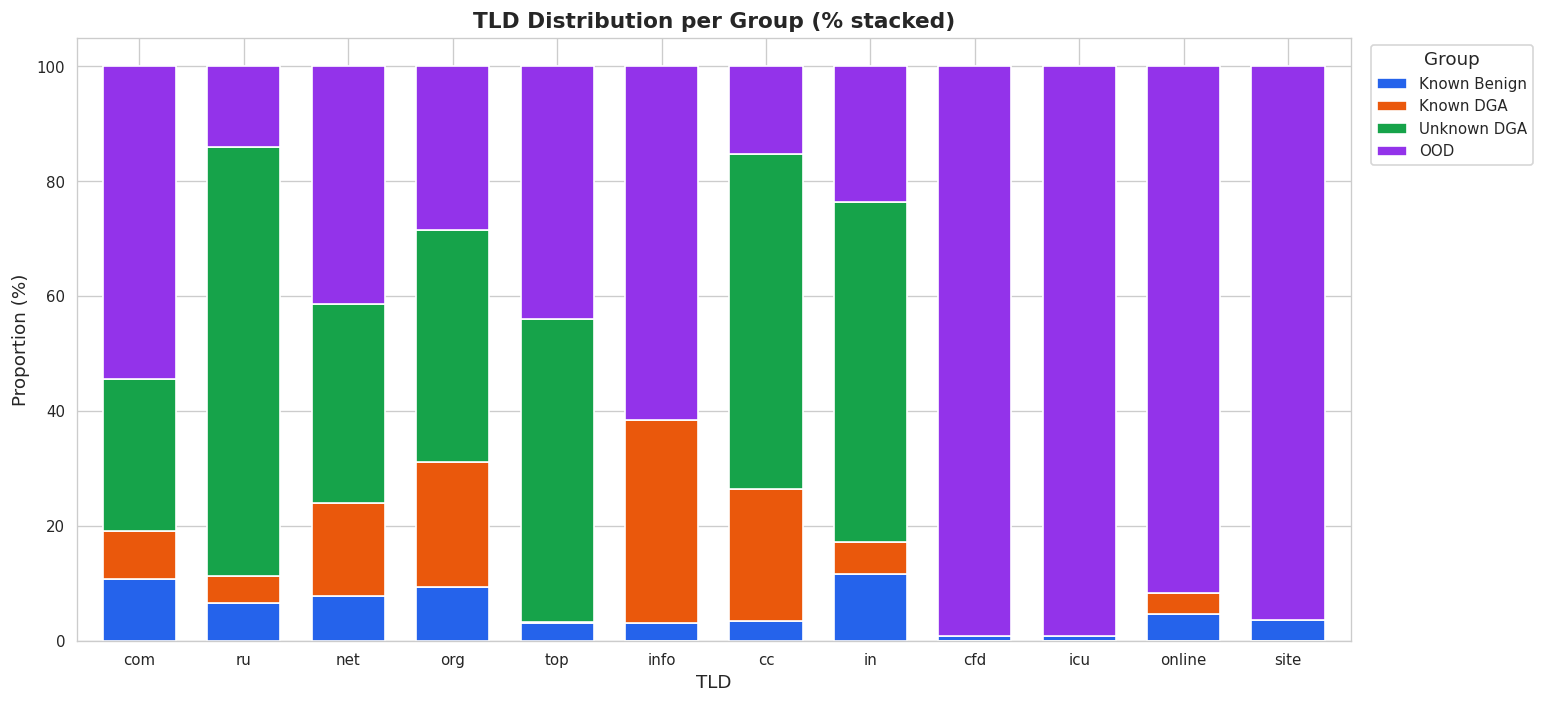

In [17]:
top_tlds  = df_all['tld'].value_counts().head(12).index.tolist()
df_tld    = df_all[df_all['tld'].isin(top_tlds)]
tld_pivot = df_tld.groupby(['tld', 'group']).size().unstack(fill_value=0)
tld_pivot = tld_pivot.reindex(top_tlds)
tld_pivot = tld_pivot[[g for g in GROUP_ORDER if g in tld_pivot.columns]]
tld_pivot_pct = tld_pivot.div(tld_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
tld_pivot_pct.plot(kind='bar', stacked=True, ax=ax,
                   color=[GROUP_COLORS[g] for g in tld_pivot_pct.columns],
                   width=0.7)
ax.set_xlabel('TLD')
ax.set_ylabel('Proportion (%)')
ax.set_title('TLD Distribution per Group (% stacked)')
ax.legend(title='Group', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_09_tld_distribution.png')
plt.show()

## 12. DGA Family Distribution

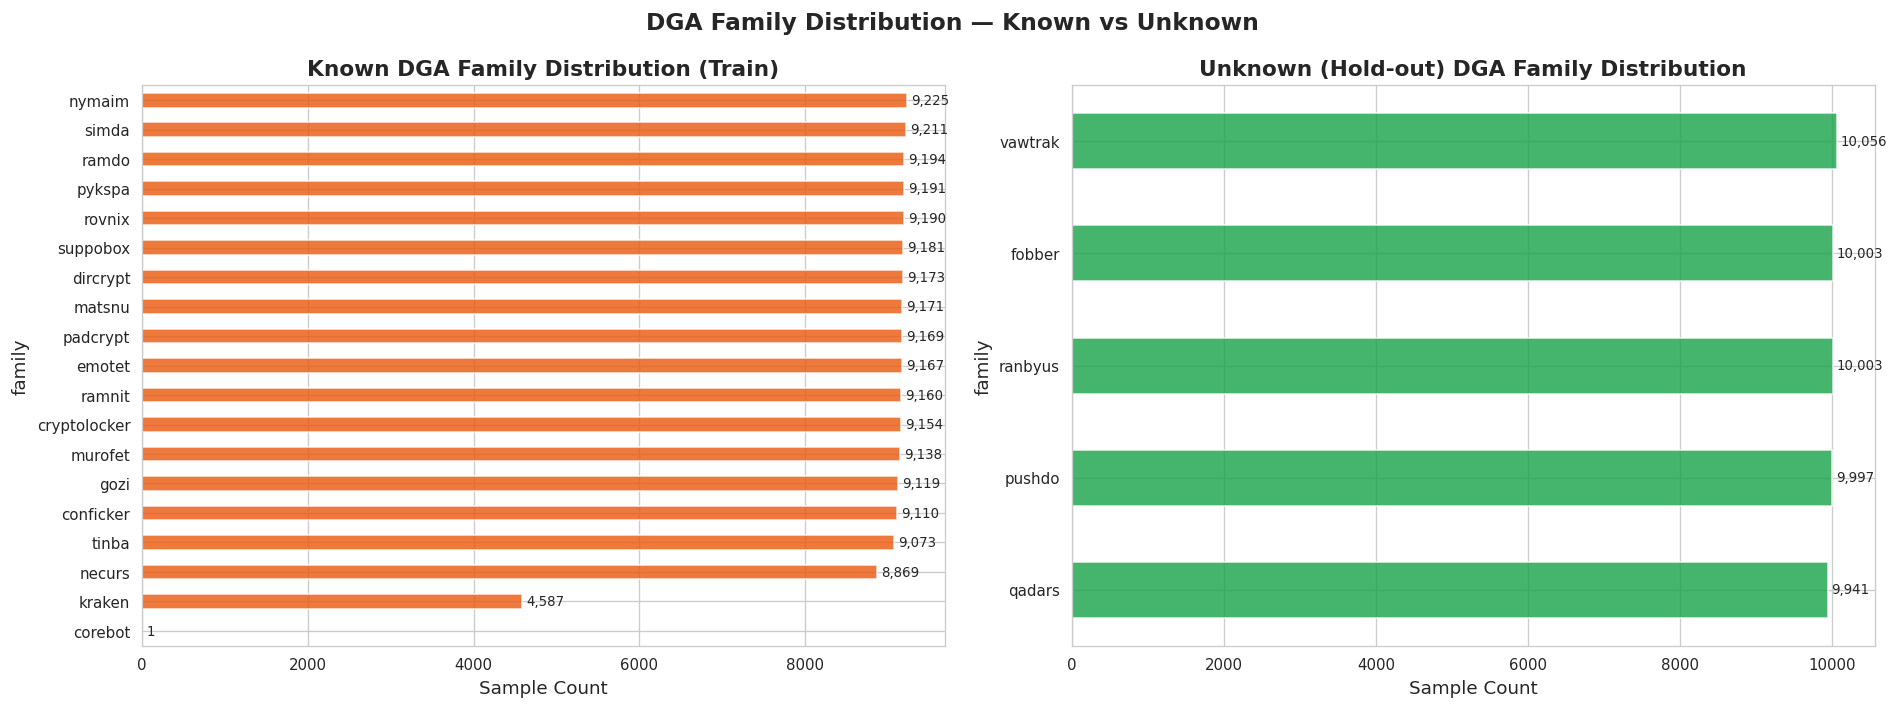

Known families in train : 19
Hold-out families       : 5
Hold-out family names   : ['fobber', 'pushdo', 'qadars', 'ranbyus', 'vawtrak']

Note: corebot has only 1 sample(s) — degenerate class.


In [18]:
family_counts = df_train[df_train['label'] == 'dga']['family'].value_counts()
unk_counts    = df_unknown_family['family'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Known families (train)
family_counts.plot(kind='barh', ax=axes[0], color='#EA580C', alpha=0.8)
axes[0].set_title('Known DGA Family Distribution (Train)')
axes[0].set_xlabel('Sample Count')
axes[0].invert_yaxis()
for i, v in enumerate(family_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# Panel B: Unknown (hold-out) families
unk_counts.plot(kind='barh', ax=axes[1], color='#16A34A', alpha=0.8)
axes[1].set_title('Unknown (Hold-out) DGA Family Distribution')
axes[1].set_xlabel('Sample Count')
axes[1].invert_yaxis()
for i, v in enumerate(unk_counts.values):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

fig.suptitle('DGA Family Distribution — Known vs Unknown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_10_family_distribution.png')
plt.show()

print(f'Known families in train : {len(family_counts)}')
print(f'Hold-out families       : {len(unk_counts)}')
print(f'Hold-out family names   : {sorted(unk_counts.index.tolist())}')
print(f'\nNote: corebot has only {family_counts.get("corebot", 0)} sample(s) — degenerate class.')

## 13. OOD Source Analysis
Verify source diversity in the OOD pool — no single source should dominate.

OOD source breakdown:
  phishing.army:phishing_army_blocklist.txt              :  40,000  ( 40.0%)
  raw.githubusercontent.com:hagezi/dns-blocklists        :  36,382  ( 36.4%)
  tranco_tail                                            :  18,891  ( 18.9%)
  raw.githubusercontent.com:stamparm/blackbook           :   3,618  (  3.6%)
  crtsh                                                  :     412  (  0.4%)
  360netlab                                              :     324  (  0.3%)
  urlhaus.abuse.ch:text_online                           :     322  (  0.3%)
  openphish.com:feed.txt                                 :      51  (  0.1%)


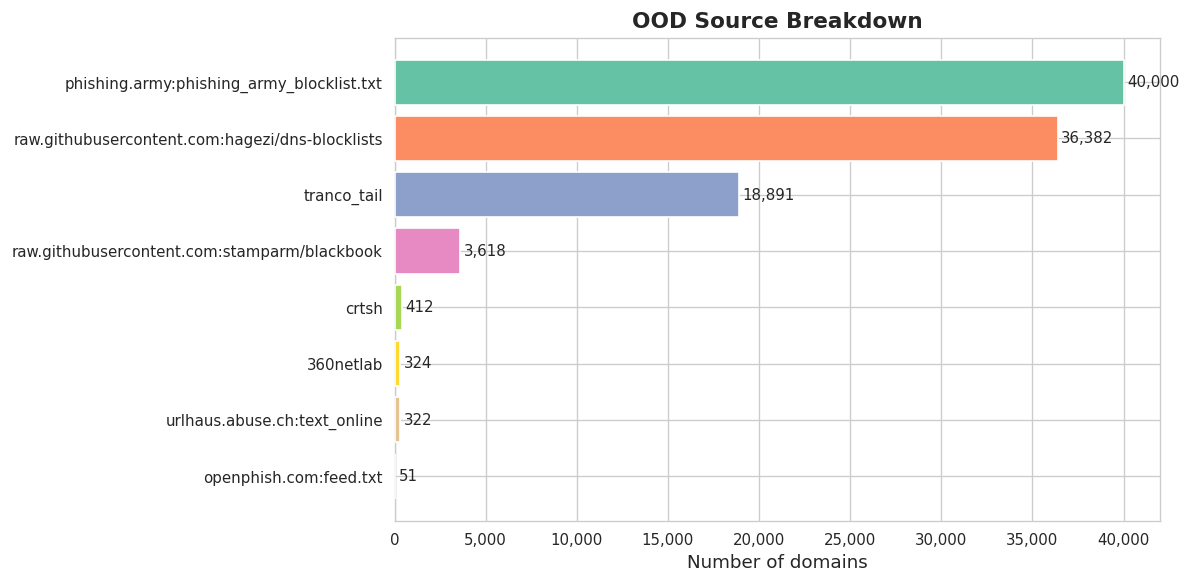

In [19]:
src_counts = df_unknown_ood['source'].value_counts()
print('OOD source breakdown:')
for src, cnt in src_counts.items():
    pct = cnt / len(df_unknown_ood) * 100
    print(f'  {src:55s}: {cnt:>7,}  ({pct:5.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
colors_src = plt.cm.Set2(np.linspace(0, 1, len(src_counts)))
bars = ax.barh(src_counts.index, src_counts.values, color=colors_src, zorder=3)
for bar, (src, cnt) in zip(bars, src_counts.items()):
    ax.text(cnt + 200, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_xlabel('Number of domains')
ax.set_title('OOD Source Breakdown')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_11_ood_source.png')
plt.show()

## 14. Domain Length Analysis

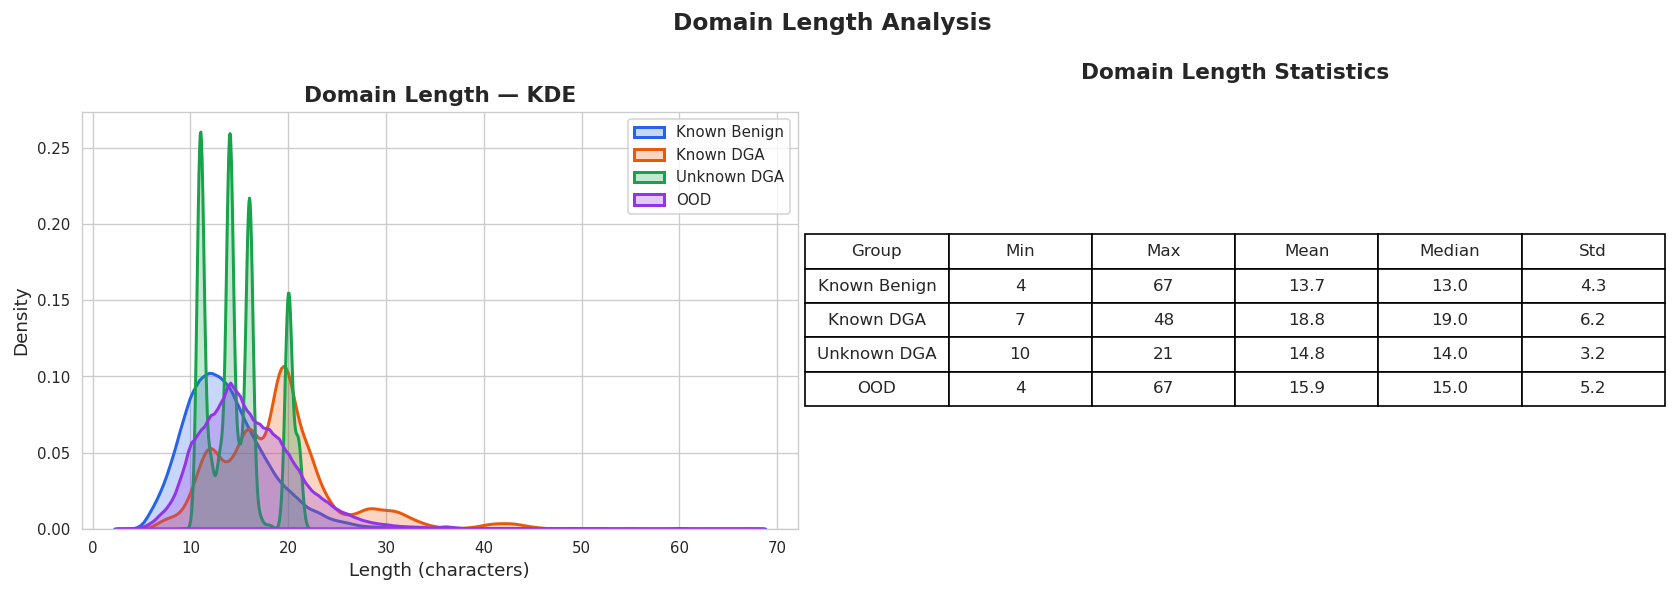

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: KDE
for group in GROUP_ORDER:
    sub = df_all[df_all['group'] == group]
    sns.kdeplot(sub['length'], ax=axes[0], label=group,
                color=GROUP_COLORS[group], fill=True, alpha=0.25, linewidth=1.8)
axes[0].set_title('Domain Length — KDE')
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Panel B: Statistics table
stats_rows = []
for group in GROUP_ORDER:
    sub = df_all[df_all['group'] == group]['length']
    stats_rows.append({
        'Group': group,
        'Min':    int(sub.min()),
        'Max':    int(sub.max()),
        'Mean':   round(sub.mean(), 1),
        'Median': round(sub.median(), 1),
        'Std':    round(sub.std(), 1)
    })
df_len_stats = pd.DataFrame(stats_rows)

axes[1].axis('off')
tbl = axes[1].table(cellText=df_len_stats.values,
                    colLabels=df_len_stats.columns,
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.9)
axes[1].set_title('Domain Length Statistics', pad=20)

fig.suptitle('Domain Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_12_domain_length.png')
plt.show()

## 15. Statistical Summary Table
Descriptive statistics (mean ± std) for all 6 features across the 4 groups.
This table can be included directly in the technical report.

In [21]:
summary_rows = []
for group in GROUP_ORDER:
    sub = df_all[df_all['group'] == group]
    row = {'Group': group, 'N': len(sub)}
    for feat, label in FEATURES:
        mean = sub[feat].mean()
        std  = sub[feat].std()
        row[label] = f'{mean:.3f} ± {std:.3f}'
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

print('Statistical Summary — Mean ± Std per Feature per Group')
print('=' * 90)
print(df_summary.to_string(index=False))
print('=' * 90)

# Also save as CSV for easy copy into report
df_summary.to_csv(FIGURE_DIR / 'eda_statistical_summary.csv', index=False)
print(f'\nSaved to {FIGURE_DIR / "eda_statistical_summary.csv"}')

Statistical Summary — Mean ± Std per Feature per Group
       Group      N Shannon Entropy   Digit Ratio   Vowel Ratio Bigram Diversity Unique Char Ratio  Domain Length
Known Benign  20043   3.076 ± 0.380 0.025 ± 0.081 0.348 ± 0.102    0.978 ± 0.048     0.770 ± 0.125 13.696 ± 4.341
   Known DGA  19957   3.390 ± 0.380 0.017 ± 0.065 0.280 ± 0.122    0.973 ± 0.046     0.698 ± 0.137 18.811 ± 6.170
 Unknown DGA  50000   3.276 ± 0.315 0.044 ± 0.099 0.311 ± 0.123    0.985 ± 0.036     0.775 ± 0.096 14.841 ± 3.196
         OOD 100000   3.258 ± 0.375 0.044 ± 0.120 0.336 ± 0.104    0.976 ± 0.047     0.744 ± 0.125 15.942 ± 5.168

Saved to ..\figures\EDA\eda_statistical_summary.csv


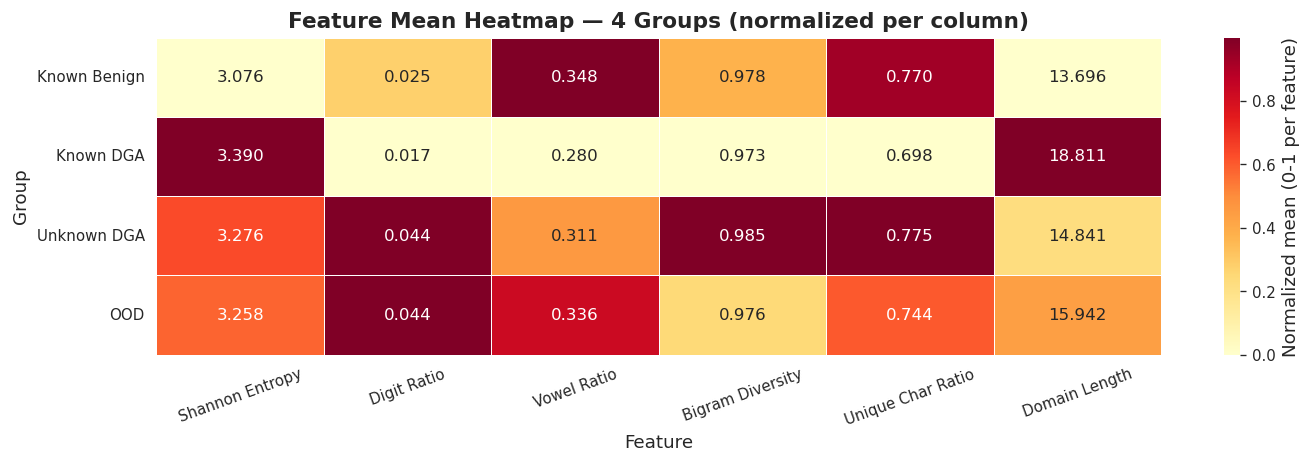

Interpretation: Darker = higher normalized mean. Known DGA shows high entropy + high bigram diversity + low vowel ratio. OOD is between Benign and DGA in most features.


In [22]:
# Visualize mean values as a heatmap for quick comparison
mean_rows = []
for group in GROUP_ORDER:
    sub = df_all[df_all['group'] == group]
    row = {label: sub[feat].mean() for feat, label in FEATURES}
    mean_rows.append(row)

df_mean = pd.DataFrame(mean_rows, index=GROUP_ORDER)

# Normalize per column (0–1) so different scales are comparable
df_mean_norm = (df_mean - df_mean.min()) / (df_mean.max() - df_mean.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df_mean_norm, annot=df_mean.round(3), fmt='.3f',
            cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Normalized mean (0-1 per feature)'},
            annot_kws={'size': 10})
ax.set_title('Feature Mean Heatmap — 4 Groups (normalized per column)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Group')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_13_feature_mean_heatmap.png')
plt.show()
print('Interpretation: Darker = higher normalized mean.'
      ' Known DGA shows high entropy + high bigram diversity + low vowel ratio.'
      ' OOD is between Benign and DGA in most features.')

## 16. Key Insights

| # | Insight | Implication |
|---|---|---|
| 1 | **Known Benign vs Known DGA** separate clearly by entropy and vowel_ratio | 6 lexical features are sufficient for closed-set binary detection |
| 2 | **Known DGA vs Unknown DGA** share similar entropy distributions (per-family boxplot) | Open-set detection is harder: unknown families blend with known DGA |
| 3 | **OOD overlaps with Benign** in t-SNE space | Model may misclassify legitimate-looking OOD domains as benign — explains lower AUROC on unknown_ood |
| 4 | **tranco_tail** in OOD has low anomaly score, similar to known benign | Benign-style OOD is the hardest negative — intentionally included as a hard negative |
| 5 | **TLD `.ru`** is over-represented in Unknown DGA vs Known DGA | Some DGA families prefer specific TLDs — TLD is a useful auxiliary feature |
| 6 | **OOD source diversity** confirmed (8 sources, no single source > 40%) | Dataset avoids source-specific bias; OOD pool reflects diverse real-world threats |
| 7 | **corebot** has only 1 sample in train | Degenerate class — per-class F1 for corebot is not statistically meaningful |